# Edge Weight & Degree Distribution Analysis
This notebook analyzes the stock similarity network by examining edge weight distributions, edge counts at various thresholds, degree distributions across thresholds, and degree centrality.

In [5]:
import sys
import os
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.abspath('.'))
from helpers import build_network, load_similarity

In [6]:
# Load similarity matrix and convert to cosine distance
sim_df = load_similarity()
cosine_dist = 1.0 - sim_df.values
dist_df = pd.DataFrame(cosine_dist, index=sim_df.index, columns=sim_df.columns)

G = build_network(dist_df)
print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Extract all edge weights once for reuse
weights = np.array([d["weight"] for u, v, d in G.edges(data=True)])

Graph built with 2441 nodes and 2978020 edges.
Graph loaded with 2441 nodes and 2978020 edges.


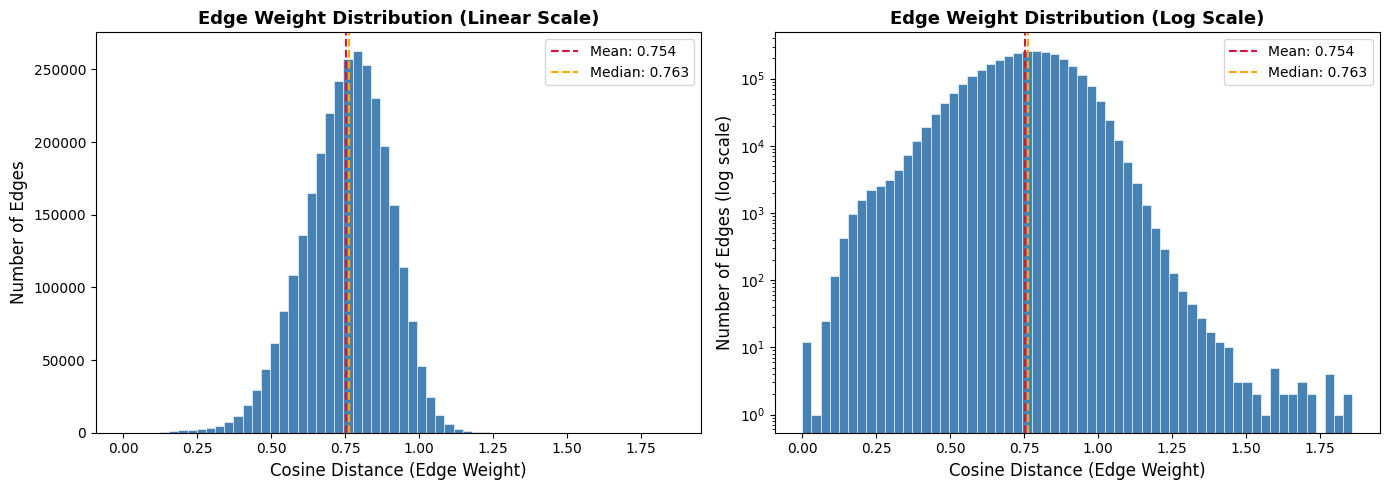


Weight stats — min: 0.0001 | mean: 0.7538 | median: 0.7631 | max: 1.8612


In [7]:
# --- Full edge weight histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(weights, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel("Cosine Distance (Edge Weight)", fontsize=12)
axes[0].set_ylabel("Number of Edges", fontsize=12)
axes[0].set_title("Edge Weight Distribution (Linear Scale)", fontsize=13, fontweight='bold')
axes[0].axvline(np.mean(weights), color='crimson', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(weights):.3f}")
axes[0].axvline(np.median(weights), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {np.median(weights):.3f}")
axes[0].legend()

# Log scale y-axis to see low-frequency tails
axes[1].hist(weights, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_yscale('log')
axes[1].set_xlabel("Cosine Distance (Edge Weight)", fontsize=12)
axes[1].set_ylabel("Number of Edges (log scale)", fontsize=12)
axes[1].set_title("Edge Weight Distribution (Log Scale)", fontsize=13, fontweight='bold')
axes[1].axvline(np.mean(weights), color='crimson', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(weights):.3f}")
axes[1].axvline(np.median(weights), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {np.median(weights):.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nWeight stats — min: {weights.min():.4f} | mean: {weights.mean():.4f} | median: {np.median(weights):.4f} | max: {weights.max():.4f}")

In [8]:
# --- Edge counts within thresholds ---
thresholds = [round(t / 10, 1) for t in range(1, 13)]  # 0.1 to 1.2

rows = []
total_edges = G.number_of_edges()
for t in thresholds:
    count = int(np.sum(weights <= t))
    rows.append({
        "Threshold (<=)": t,
        "Edges Kept": count,
        "Edges Removed": total_edges - count,
        "% Kept": f"{100 * count / total_edges:.1f}%",
    })

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))

 Threshold (<=)  Edges Kept  Edges Removed % Kept
            0.1          51        2977969   0.0%
            0.2        2153        2975867   0.1%
            0.3        9752        2968268   0.3%
            0.4       32773        2945247   1.1%
            0.5      132705        2845315   4.5%
            0.6      423293        2554727  14.2%
            0.7      994266        1983754  33.4%
            0.8     1799729        1178291  60.4%
            0.9     2538311         439709  85.2%
            1.0     2897343          80677  97.3%
            1.1     2970181           7839  99.7%
            1.2     2977232            788 100.0%


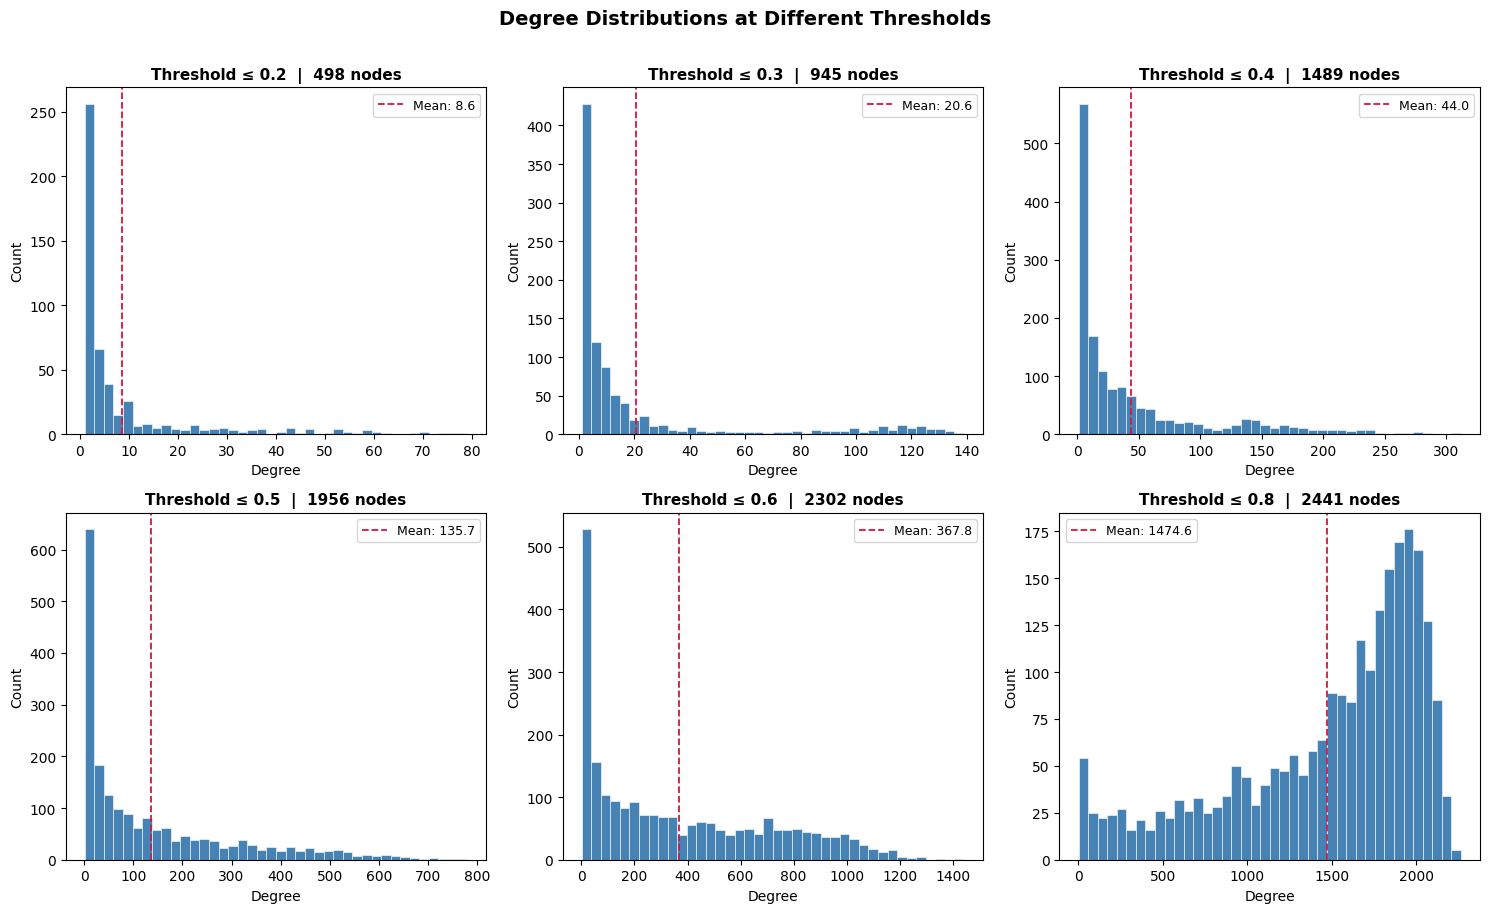

In [9]:
def build_thresholded_graph(threshold):
    """Return a subgraph keeping only edges with weight <= threshold (isolated nodes removed)."""
    edges_to_keep = [(u, v, d) for u, v, d in G.edges(data=True) if d.get('weight', 1.0) <= threshold]
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(edges_to_keep)
    H.remove_nodes_from(list(nx.isolates(H)))
    return H

# Plot degree distributions for a selection of thresholds side-by-side
plot_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, t in zip(axes, plot_thresholds):
    H = build_thresholded_graph(t)
    degrees = [d for _, d in H.degree()]
    ax.hist(degrees, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(f"Threshold ≤ {t}  |  {H.number_of_nodes()} nodes", fontsize=11, fontweight='bold')
    ax.set_xlabel("Degree", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.axvline(np.mean(degrees), color='crimson', linestyle='--', linewidth=1.3, label=f"Mean: {np.mean(degrees):.1f}")
    ax.legend(fontsize=9)

plt.suptitle("Degree Distributions at Different Thresholds", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

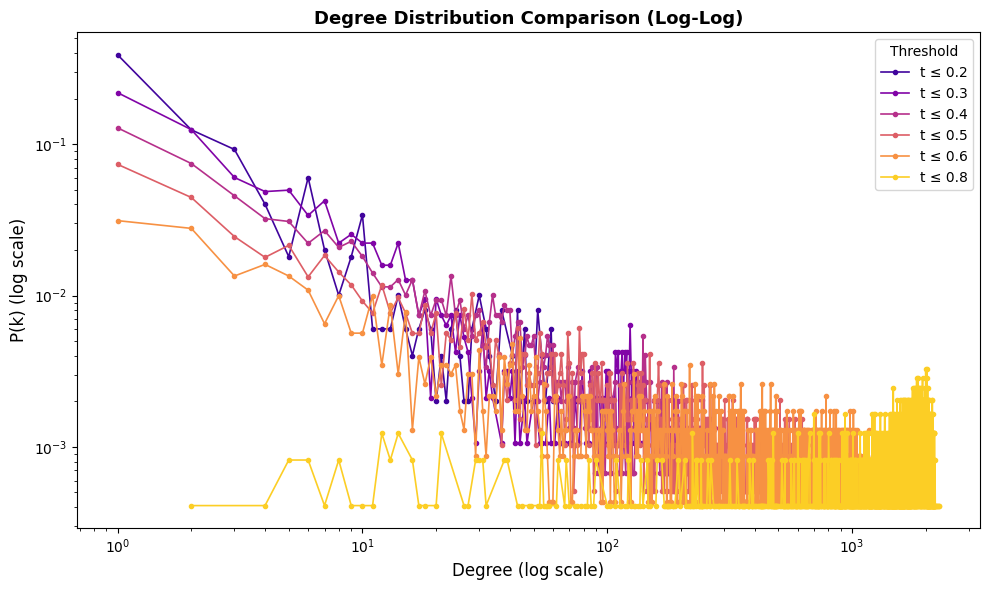

In [10]:
# Overlaid degree distributions (log-log) to compare power-law behaviour
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(plot_thresholds)))

for color, t in zip(colors, plot_thresholds):
    H = build_thresholded_graph(t)
    degrees = sorted([d for _, d in H.degree()])
    # Probability distribution
    degree_counts = np.bincount(degrees)
    degree_vals = np.nonzero(degree_counts)[0]
    probs = degree_counts[degree_vals] / degree_counts[degree_vals].sum()
    ax.plot(degree_vals, probs, marker='o', markersize=3, linewidth=1.2, label=f"t ≤ {t}", color=color)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Degree (log scale)", fontsize=12)
ax.set_ylabel("P(k) (log scale)", fontsize=12)
ax.set_title("Degree Distribution Comparison (Log-Log)", fontsize=13, fontweight='bold')
ax.legend(title="Threshold")
plt.tight_layout()
plt.show()

In [11]:
# --- Degree Centrality Analysis ---
# Compute for each threshold: centrality scores, top hubs, and summary stats

centrality_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in centrality_thresholds:
    H = build_thresholded_graph(t)
    centrality = nx.degree_centrality(H)
    ranked = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    scores = np.array([v for _, v in ranked])
    raw_degrees = scores * (H.number_of_nodes() - 1)

    print(f"── Threshold ≤ {t} | {H.number_of_nodes()} nodes ─────────────────────")
    print(f"  Top 5 hubs:")
    for ticker, score in ranked[:5]:
        print(f"    {ticker:6s}  degree = {score * (H.number_of_nodes() - 1):6.1f}  centrality = {score:.4f}")
    p = np.percentile(scores, [25, 50, 75])
    print(f"  Centrality — min: {scores.min():.4f}  Q1: {p[0]:.4f}  median: {p[1]:.4f}  Q3: {p[2]:.4f}  max: {scores.max():.4f}\n")

── Threshold ≤ 0.2 | 498 nodes ─────────────────────
  Top 5 hubs:
    CATY    degree =   79.0  centrality = 0.1590
    FCF     degree =   76.0  centrality = 0.1529
    ABCB    degree =   74.0  centrality = 0.1489
    FRME    degree =   71.0  centrality = 0.1429
    HOPE    degree =   70.0  centrality = 0.1408
  Centrality — min: 0.0020  Q1: 0.0020  median: 0.0040  Q3: 0.0161  max: 0.1590

── Threshold ≤ 0.3 | 945 nodes ─────────────────────
  Top 5 hubs:
    CATY    degree =  139.0  centrality = 0.1472
    HWC     degree =  136.0  centrality = 0.1441
    ABCB    degree =  135.0  centrality = 0.1430
    FCF     degree =  135.0  centrality = 0.1430
    ASB     degree =  134.0  centrality = 0.1419
  Centrality — min: 0.0011  Q1: 0.0021  median: 0.0053  Q3: 0.0169  max: 0.1472

── Threshold ≤ 0.4 | 1489 nodes ─────────────────────
  Top 5 hubs:
    HWC     degree =  312.0  centrality = 0.2097
    ITT     degree =  307.0  centrality = 0.2063
    FITB    degree =  289.0  centrality = 0.1942

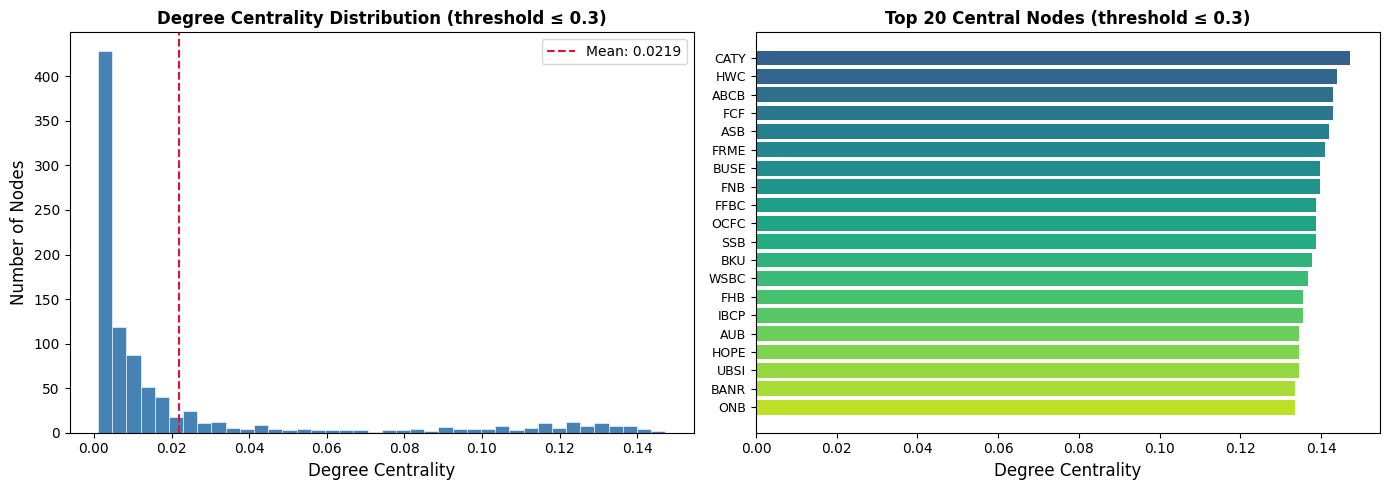

In [12]:
# Centrality histogram + top-20 ranked bar chart for a chosen threshold
FOCUS_THRESHOLD = 0.3

H = build_thresholded_graph(FOCUS_THRESHOLD)
centrality = nx.degree_centrality(H)
ranked = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
scores = np.array([v for _, v in ranked])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all centrality scores
axes[0].hist(scores, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel("Degree Centrality", fontsize=12)
axes[0].set_ylabel("Number of Nodes", fontsize=12)
axes[0].set_title(f"Degree Centrality Distribution (threshold ≤ {FOCUS_THRESHOLD})", fontsize=12, fontweight='bold')
axes[0].axvline(scores.mean(), color='crimson', linestyle='--', linewidth=1.5, label=f"Mean: {scores.mean():.4f}")
axes[0].legend()

# Top-20 nodes ranked bar chart
top20_tickers = [t for t, _ in ranked[:20]]
top20_scores = [s for _, s in ranked[:20]]
bar_colors = plt.cm.viridis(np.linspace(0.3, 0.9, 20))
axes[1].barh(top20_tickers[::-1], top20_scores[::-1], color=bar_colors[::-1])
axes[1].set_xlabel("Degree Centrality", fontsize=12)
axes[1].set_title(f"Top 20 Central Nodes (threshold ≤ {FOCUS_THRESHOLD})", fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

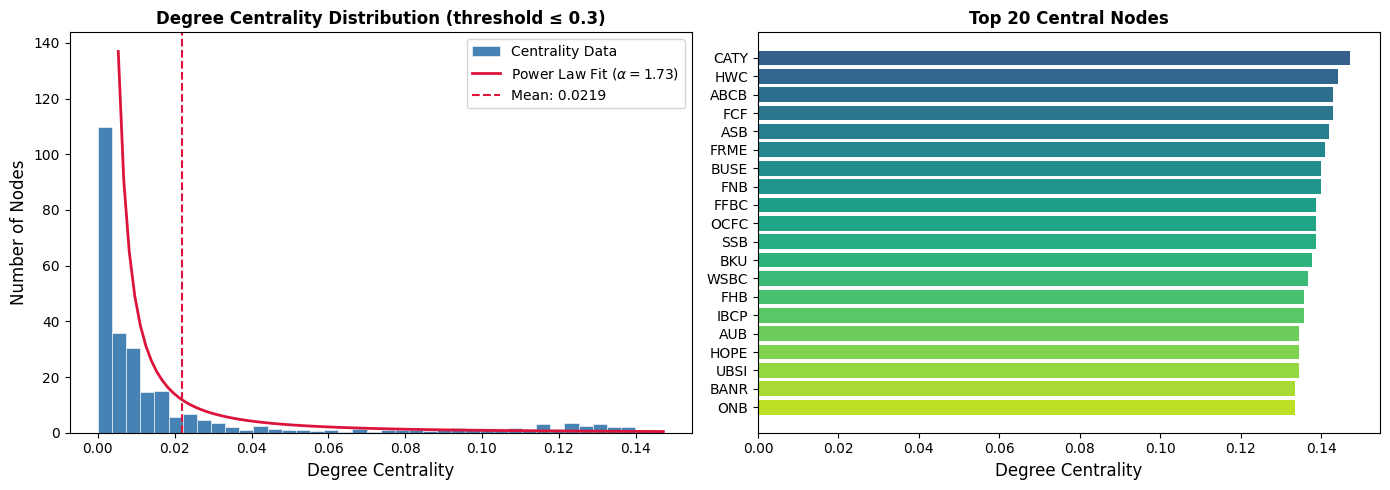

In [26]:
import powerlaw
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Centrality Data
H = build_thresholded_graph(FOCUS_THRESHOLD)
centrality = nx.degree_centrality(H)
ranked = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
scores = np.array([v for _, v in ranked])

# 2. Perform Power Law Fit
fit = powerlaw.Fit(scores, verbose=False)
alpha = fit.alpha

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Axis: Histogram with Consistent Bins ---
# We define equal-width bins manually from 0 to the max score
n_bins = 40
bin_edges = np.linspace(0, scores.max(), n_bins + 1)

# Use density=True so the Power Law curve can scale to the data
axes[0].hist(scores, bins=bin_edges, color='steelblue', 
             edgecolor='white', linewidth=0.4, 
             density=True, label='Centrality Data')

# Generate smooth X values for the power law curve starting from xmin
x_curve = np.linspace(fit.xmin, scores.max(), 100)
# Formula: P(x) = C * x^-alpha (normalized to the data)
y_curve = fit.power_law.pdf(x_curve)

axes[0].plot(x_curve, y_curve, color='crimson', linestyle='-', 
             linewidth=2, label=f'Power Law Fit ($\\alpha={alpha:.2f}$)')

axes[0].set_xlabel("Degree Centrality", fontsize=12)
axes[0].set_ylabel("Number of Nodes", fontsize=12)
axes[0].set_title(f"Degree Centrality Distribution (threshold ≤ {FOCUS_THRESHOLD})", fontsize=12, fontweight='bold')
axes[0].axvline(scores.mean(), color='crimson', linestyle='--', linewidth=1.5, label=f"Mean: {scores.mean():.4f}")
axes[0].legend()

# --- Right Axis: Top-20 Bar Chart ---
top20_tickers = [t for t, _ in ranked[:20]]
top20_scores = [s for _, s in ranked[:20]]
bar_colors = plt.cm.viridis(np.linspace(0.3, 0.9, 20))
axes[1].barh(top20_tickers[::-1], top20_scores[::-1], color=bar_colors[::-1])
axes[1].set_xlabel("Degree Centrality", fontsize=12)
axes[1].set_title(f"Top 20 Central Nodes", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()